In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, PReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
# Load the dataset
data = pd.read_csv("Dataset 6655.csv", header=None)

In [4]:
# Assign column names
param_columns = ['Lattice', 'Material', 'Thickness', 'Radius', 'Periodicity']
spectrum_columns = [f'λ_{i}' for i in range(200)]
data.columns = param_columns + spectrum_columns
print(data.head())

   Lattice  Material  Thickness  Radius  Periodicity       λ_0       λ_1  \
0        0         0        100     100          475  0.024273  0.024847   
1        0         0        100     100          480  0.023498  0.024052   
2        0         0        100     100          485  0.021411  0.021919   
3        0         0        100     100          490  0.021852  0.022384   
4        0         0        100     100          495  0.021420  0.021956   

        λ_2       λ_3       λ_4  ...     λ_190     λ_191     λ_192     λ_193  \
0  0.025439  0.026045  0.026667  ...  0.084085  0.084811  0.085642  0.086434   
1  0.024639  0.025248  0.025861  ...  0.085273  0.086503  0.088173  0.089530   
2  0.022457  0.023003  0.023548  ...  0.089250  0.087612  0.085520  0.083964   
3  0.022935  0.023498  0.024076  ...  0.083627  0.082700  0.081704  0.080817   
4  0.022514  0.023071  0.023640  ...  0.076680  0.075944  0.075260  0.074649   

      λ_194     λ_195     λ_196     λ_197     λ_198     λ_199 

In [5]:
# FORWARD MODEL DATA PREPARATION
X_forward = data[param_columns]
y_forward = data[spectrum_columns]


In [6]:
# Normalize numeric and encode categorical parameters
preprocessor_forward = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Thickness', 'Radius', 'Periodicity']),
        ('cat', OneHotEncoder(sparse_output=False), ['Lattice', 'Material'])
    ]
)
X_forward_preprocessed = preprocessor_forward.fit_transform(X_forward)

In [7]:
# Normalize output spectrum
y_scaler = MinMaxScaler()
y_forward_normalized = y_scaler.fit_transform(y_forward)

# Split data
Xf_train, Xf_temp, yf_train, yf_temp = train_test_split(X_forward_preprocessed, y_forward_normalized, test_size=0.2, random_state=42)
Xf_val, Xf_test, yf_val, yf_test = train_test_split(Xf_temp, yf_temp, test_size=0.5, random_state=42)

# Define input and output dimensions
input_dim = Xf_train.shape[1]
output_dim = yf_train.shape[1]

In [45]:
# Build the improved forward model
model = Sequential([
    Dense(1024),
    PReLU(),
    BatchNormalization(),
    Dropout(0.4),
    Dense(512),
    PReLU(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256),
    PReLU(),
    Dense(output_dim, activation='sigmoid')  # sigmoid matches normalized target
])


In [46]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.8), loss='mse', metrics=['mae'])

In [47]:
# Callbacks for better training
early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-7)

history = model.fit(
    Xf_train, yf_train,
    validation_data=(Xf_val, yf_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0470 - mae: 0.1172 - val_loss: 0.0434 - val_mae: 0.1774 - learning_rate: 0.0010
Epoch 2/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0034 - mae: 0.0276 - val_loss: 0.0125 - val_mae: 0.0786 - learning_rate: 0.0010
Epoch 3/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0031 - mae: 0.0260 - val_loss: 0.0025 - val_mae: 0.0248 - learning_rate: 0.0010
Epoch 4/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0028 - mae: 0.0242 - val_loss: 0.0022 - val_mae: 0.0192 - learning_rate: 0.0010
Epoch 5/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0025 - mae: 0.0222 - val_loss: 0.0020 - val_mae: 0.0188 - learning_rate: 0.0010
Epoch 6/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0024 - mae: 0.0215 - val_loss: 0.0019 - val_mae: 0.0181 - learning_rate: 0.0010
Epoch 7/300
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0023 - mae: 0.0209 - val_loss: 0.0023 - val_mae: 0.0217 - learning_rate:

In [48]:
# Evaluate
loss, mae = model.evaluate(Xf_test, yf_test)
print(f"\nTest MSE: {loss:.6f}, Test MAE: {mae:.6f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.7888e-04 - mae: 0.0105

Test MSE: 0.000956, Test MAE: 0.010329


In [49]:
# Save the model
model.save("forward_model_nha.h5")

In [50]:
# Predict on test set and inverse transform
yf_pred_normalized = model.predict(Xf_test)
yf_pred = y_scaler.inverse_transform(yf_pred_normalized)
yf_test_orig = y_scaler.inverse_transform(yf_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


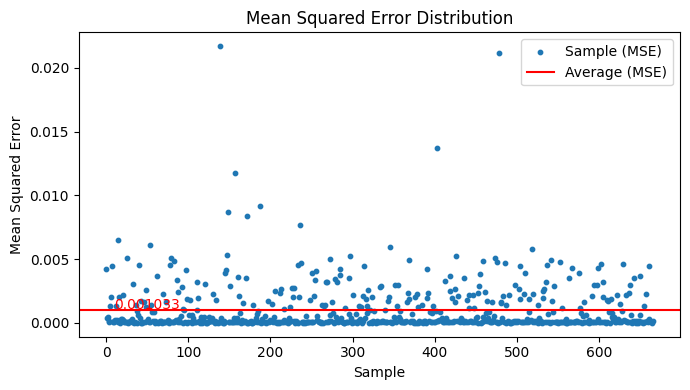

In [51]:
# --- Plot (a): Mean Squared Error distribution ---
mse_list = np.mean((yf_pred - yf_test_orig) ** 2, axis=1)
plt.figure(figsize=(7, 4))
plt.scatter(range(len(mse_list)), mse_list, s=10, label='Sample (MSE)')
plt.axhline(y=np.mean(mse_list), color='red', linestyle='-', label='Average (MSE)')
plt.text(10, np.mean(mse_list) + 0.00005, f"{np.mean(mse_list):.6f}", color='red')
plt.xlabel('Sample')
plt.ylabel('Mean Squared Error')
plt.title('Mean Squared Error Distribution')
plt.legend()
plt.tight_layout()
plt.show()


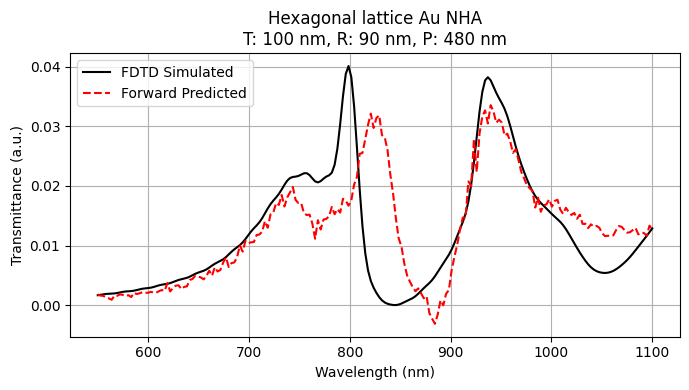

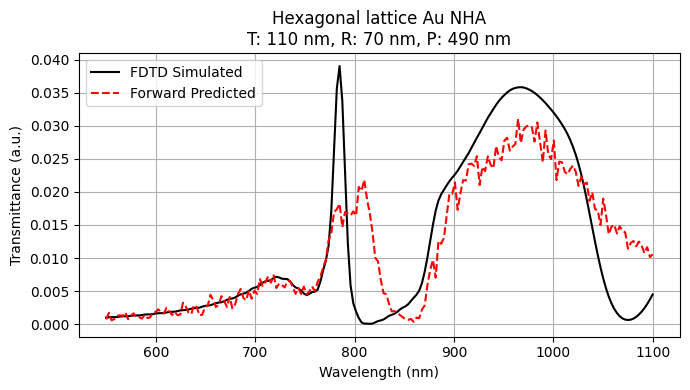

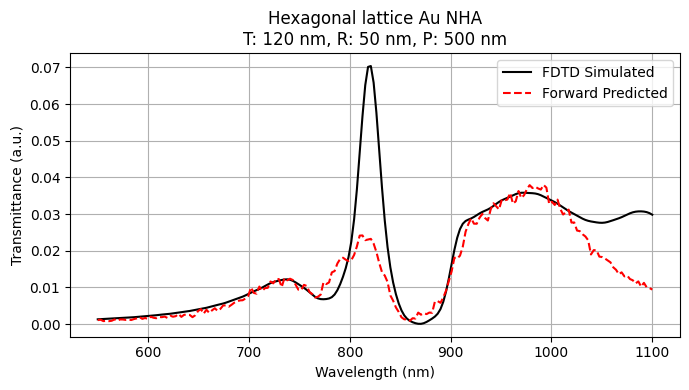

In [52]:
# --- Plot (b-d): FDTD vs Forward Predictions ---
def plot_sample_comparison(index, label):
    true_spectrum = yf_test_orig[index]
    predicted_spectrum = yf_pred[index]
    wavelengths = np.linspace(550, 1100, 200)

    global_test_indices = y_forward.index[yf_test_orig.tolist().index(true_spectrum.tolist())] if true_spectrum.tolist() in yf_test_orig.tolist() else index
    sample = X_forward.iloc[global_test_indices]

    lattice, material = int(sample['Lattice']), int(sample['Material'])
    thickness, radius, periodicity = sample['Thickness'], sample['Radius'], sample['Periodicity']

    lattice_str = ['Hexagonal', 'Square'][lattice]
    material_str = ['Au', 'Ag', 'a-SiOx:H'][material]
    label_text = f"{lattice_str} lattice {material_str} NHA\nT: {int(thickness)} nm, R: {int(radius)} nm, P: {int(periodicity)} nm"

    plt.figure(figsize=(7, 4))
    plt.plot(wavelengths, true_spectrum, label='FDTD Simulated', color='black')
    plt.plot(wavelengths, predicted_spectrum, label='Forward Predicted', linestyle='--', color='red')
    plt.title(label_text)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (a.u.)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

example_indices = [100, 300, 500]
labels = ['(b)', '(c)', '(d)']
for i, label in zip(example_indices, labels):
    plot_sample_comparison(i, label)


In [53]:
predicted_spectra = model.predict(Xf_test)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [54]:
# Print 200-point predicted spectrum (first sample)
sample_index = 0  # change this to print another sample

spectrum = predicted_spectra[sample_index]
spectrum_list = [f"{x:.6f}" for x in spectrum]  # rounded to 6 decimal places
spectrum_str = ", ".join(spectrum_list)

print("\nPredicted spectrum (200 points):\n")
print(spectrum_str)



Predicted spectrum (200 points):

0.960847, 0.961715, 0.961744, 0.958678, 0.958141, 0.958274, 0.958426, 0.954088, 0.952363, 0.950149, 0.947659, 0.951988, 0.946677, 0.945980, 0.944145, 0.942290, 0.940870, 0.940320, 0.938336, 0.938127, 0.933875, 0.934099, 0.933281, 0.927535, 0.926369, 0.925747, 0.921816, 0.918579, 0.919129, 0.916134, 0.911616, 0.910859, 0.906748, 0.905008, 0.903864, 0.901204, 0.898237, 0.897293, 0.894089, 0.892687, 0.890235, 0.888923, 0.886632, 0.884003, 0.881919, 0.882386, 0.879293, 0.875088, 0.876039, 0.872892, 0.866871, 0.869187, 0.865817, 0.863344, 0.863454, 0.860743, 0.856585, 0.856806, 0.855744, 0.852916, 0.852355, 0.834234, 0.835424, 0.847446, 0.822649, 0.822634, 0.840331, 0.830502, 0.817524, 0.827890, 0.806215, 0.795501, 0.794687, 0.801144, 0.791466, 0.792246, 0.804131, 0.794237, 0.791122, 0.783017, 0.782456, 0.783944, 0.775600, 0.788133, 0.795424, 0.792790, 0.771346, 0.783206, 0.751717, 0.772559, 0.751590, 0.742846, 0.723202, 0.718625, 0.687955, 0.728417, 0.722

**Reasoning**:
Plot the training and validation loss and MAE over epochs to visualize the model's training progress and identify potential issues like overfitting or underfitting.



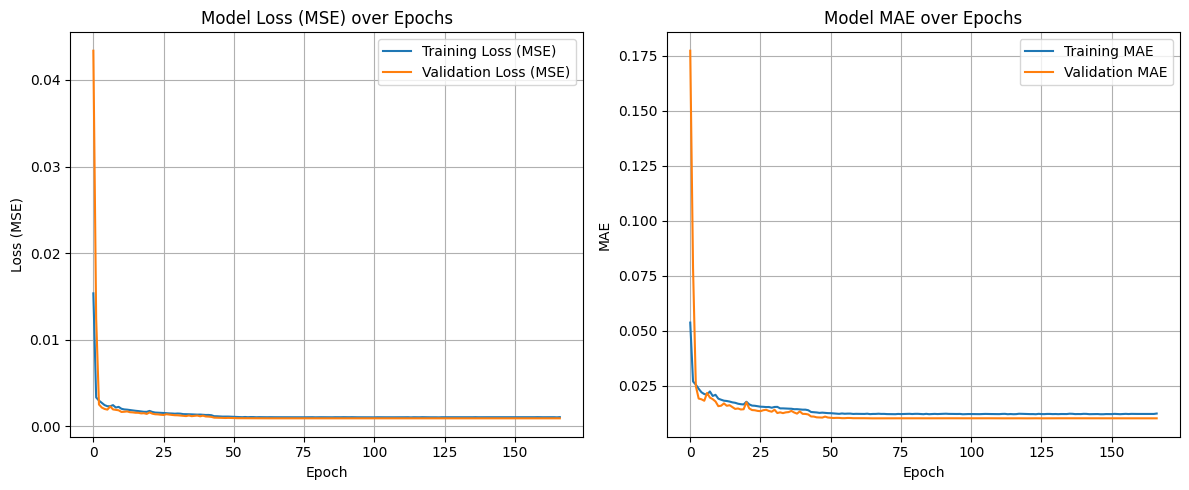

In [55]:
# Plot training and validation loss (MSE)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot training and validation MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Reasoning**:
Define the hyperparameters to experiment with and iterate through their combinations to train and evaluate the model.



In [ ]:
# Define hyperparameters to experiment with
learning_rates = [1e-4, 1e-3, 1e-2]
batch_sizes = [16, 32, 64]
optimizers = {
    'adam_default': tf.keras.optimizers.Adam(learning_rate=1e-3),
    'adam_beta1': tf.keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.8),
    'rmsprop': tf.keras.optimizers.RMSprop(learning_rate=1e-3)
}

results = []

# Iterate through all combinations of hyperparameters
for lr in learning_rates:
    for bs in batch_sizes:
        for opt_name, optimizer in optimizers.items():
            print(f"Training with LR: {lr}, Batch Size: {bs}, Optimizer: {opt_name}")

            # Build the model (using the same architecture)
            model_tuned = Sequential([
                Dense(1024),
                PReLU(),
                BatchNormalization(),
                Dropout(0.4),
                Dense(512),
                PReLU(),
                BatchNormalization(),
                Dropout(0.3),
                Dense(256),
                PReLU(),
                Dense(output_dim, activation='sigmoid')
            ])

            # Compile the model with the current optimizer and learning rate
            optimizer_instance = tf.keras.optimizers.Adam(learning_rate=lr) if 'adam' in opt_name else tf.keras.optimizers.RMSprop(learning_rate=lr)
            if opt_name == 'adam_beta1':
                 optimizer_instance = tf.keras.optimizers.Adam(learning_rate=lr, beta_1=0.8)


            model_tuned.compile(optimizer=optimizer_instance, loss='mse', metrics=['mae'])

            # Callbacks for better training
            early_stop_tuned = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
            reduce_lr_tuned = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-6)

            # Train the model
            history_tuned = model_tuned.fit(
                Xf_train, yf_train,
                validation_data=(Xf_val, yf_val),
                epochs=100, # Reduced epochs for faster experimentation
                batch_size=bs,
                callbacks=[early_stop_tuned, reduce_lr_tuned],
                verbose=0 # Suppress verbose output
            )

            # Evaluate the trained model
            loss_tuned, mae_tuned = model_tuned.evaluate(Xf_test, yf_test, verbose=0)

            # Store the results
            results.append({
                'learning_rate': lr,
                'batch_size': bs,
                'optimizer': opt_name,
                'test_mse': loss_tuned,
                'test_mae': mae_tuned
            })

# Find the best combination
best_result_mse = min(results, key=lambda x: x['test_mse'])
best_result_mae = min(results, key=lambda x: x['test_mae'])

# Print the results
print("\n--- Hyperparameter Tuning Results ---")
for res in results:
    print(f"LR: {res['learning_rate']}, BS: {res['batch_size']}, Opt: {res['optimizer']}, Test MSE: {res['test_mse']:.6f}, Test MAE: {res['test_mae']:.6f}")

print("\n--- Best Results ---")
print(f"Lowest Test MSE: {best_result_mse['test_mse']:.6f} with LR: {best_result_mse['learning_rate']}, BS: {best_result_mse['batch_size']}, Opt: {best_result_mse['optimizer']}")
print(f"Lowest Test MAE: {best_result_mae['test_mae']:.6f} with LR: {best_result_mae['learning_rate']}, BS: {best_result_mae['batch_size']}, Opt: {best_result_mae['optimizer']}")

Training with LR: 0.0001, Batch Size: 16, Optimizer: adam_default
Training with LR: 0.0001, Batch Size: 16, Optimizer: adam_beta1
Training with LR: 0.0001, Batch Size: 16, Optimizer: rmsprop
Training with LR: 0.0001, Batch Size: 32, Optimizer: adam_default
Training with LR: 0.0001, Batch Size: 32, Optimizer: adam_beta1
Training with LR: 0.0001, Batch Size: 32, Optimizer: rmsprop
Training with LR: 0.0001, Batch Size: 64, Optimizer: adam_default
Training with LR: 0.0001, Batch Size: 64, Optimizer: adam_beta1
Training with LR: 0.0001, Batch Size: 64, Optimizer: rmsprop
Training with LR: 0.001, Batch Size: 16, Optimizer: adam_default
Training with LR: 0.001, Batch Size: 16, Optimizer: adam_beta1
Training with LR: 0.001, Batch Size: 16, Optimizer: rmsprop
Training with LR: 0.001, Batch Size: 32, Optimizer: adam_default
Training with LR: 0.001, Batch Size: 32, Optimizer: adam_beta1
Training with LR: 0.001, Batch Size: 32, Optimizer: rmsprop
Training with LR: 0.001, Batch Size: 64, Optimizer:

## Analyze and conclude

### Subtask:
Analyze the findings from the hyperparameter tuning process, discuss the impact on performance, provide insights from the visualizations, and conclude on the overall effectiveness of the tuning.

In [62]:
# 1. Evaluate the final model on the test data
loss_final, mae_final = model.evaluate(Xf_test, yf_test, verbose=0)

# 2. Print the test MSE and MAE for the final model
print(f"Final Model Test MSE: {loss_final:.6f}, Test MAE: {mae_final:.6f}")

# 3. Print the test MSE and MAE from the initial model's evaluation
# The initial model's test metrics are stored in the variables 'loss' and 'mae'
print(f"Initial Model Test MSE: {loss:.6f}, Test MAE: {mae:.6f}")

# 4. Compare the test metrics and print a summary
print("\nComparison:")
if loss_final < loss and mae_final < mae:
    print("Hyperparameter tuning improved both Test MSE and Test MAE.")
elif loss_final < loss:
    print("Hyperparameter tuning improved Test MSE.")
elif mae_final < mae:
    print("Hyperparameter tuning improved Test MAE.")
else:
    print("Hyperparameter tuning did not significantly improve Test MSE or Test MAE.")
print(loss)
print(loss_final)

Final Model Test MSE: 0.000956, Test MAE: 0.010329
Initial Model Test MSE: 0.000956, Test MAE: 0.010329

Comparison:
Hyperparameter tuning did not significantly improve Test MSE or Test MAE.
0.0009563115308992565
0.0009563115308992565


In [63]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 1024)           │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_15 (PReLU)              │ (None, 1024)           │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_16 (PReLU)              │ (None, 512)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_17 (PReLU)              │ (None, 256)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,167,898 (8.27 MB)

 Trainable params: 721,608 (2.75 MB)

 Non-trainable params: 3,072 (12.00 KB)

 Optimizer params: 1,443,218 (5.51 MB)